In [6]:
!pip install -q kagglehub

In [5]:
import kagglehub

# Download the latest version
path = kagglehub.dataset_download(
    "saireddypothireddy/human-data-sequence-dataset"
)

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'human-data-sequence-dataset' dataset.
Dataset downloaded to: /kaggle/input/human-data-sequence-dataset


In [13]:
import pandas as pd
import kagglehub

# Check if 'path' is defined in the global scope; if not, re-download the dataset.
# This makes the cell more robust against kernel restarts or out-of-order execution.
if 'path' not in globals():
    print("Variable 'path' not found, re-downloading dataset...")
    path = kagglehub.dataset_download(
        "saireddypothireddy/human-data-sequence-dataset"
    )
    print("Dataset re-downloaded to:", path)

# Construct the full path to the correct dataset file (Human Data Sequnence.txt)
data_file_path = f"{path}/Human Data Sequnence.txt"

# Load the dataset, explicitly specifying tab as the delimiter
df = pd.read_csv(data_file_path, sep='\t')

# Display the first 5 rows of the DataFrame
display(df.head())

,sequence,class
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3


In [7]:
import os

# List contents of the path to identify the actual location of human_data.csv
print(f"Contents of the downloaded directory '{path}':")
for root, dirs, files in os.walk(path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Contents of the downloaded directory '/kaggle/input/human-data-sequence-dataset':
/kaggle/input/human-data-sequence-dataset/Human Data Sequnence.txt
/kaggle/input/human-data-sequence-dataset/.nfs00000000a9763d830000015c


In [11]:
# Display general information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   sequence	class  4380 non-null   object
dtypes: object(1)
memory usage: 34.3+ KB


In [14]:
# Check the distribution of the target variable 'class'
print("Class distribution:")
display(df['class'].value_counts())

# Also check the length distribution of sequences
df['sequence_length'] = df['sequence'].apply(len)
print("\nSequence length distribution:")
display(df['sequence_length'].describe())

Class distribution:


,count
class,
6,1343
4,711
3,672
1,534
0,531
2,349
5,240



Sequence length distribution:


,sequence_length
count,4380.000000
mean,1263.598630
std,1280.754087
min,5.000000
25%,405.000000
50%,865.000000
75%,1662.000000
max,18921.000000


### Data Preprocessing for Deep Learning

In [20]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Define a function to one-hot encode DNA sequences
def one_hot_encode_dna(sequence):
    mapping = {'A': [1, 0, 0, 0], 'C': [0, 1, 0, 0], 'G': [0, 0, 1, 0], 'T': [0, 0, 0, 1], 'N': [0, 0, 0, 0]}
    encoded_sequence = [mapping.get(char, [0, 0, 0, 0]) for char in sequence]
    return np.array(encoded_sequence)

# Determine the maximum sequence length for padding
max_sequence_length = df['sequence_length'].max()
print(f"Maximum sequence length: {max_sequence_length}")

# One-hot encode all sequences (this will create a list of arrays, potentially of different lengths)
encoded_sequences = [one_hot_encode_dna(seq) for seq in df['sequence']]

# Pad the sequences to the maximum length
X = pad_sequences(encoded_sequences, maxlen=max_sequence_length, padding='post', dtype='float32')

# Encode target labels (already numerical, but for consistency with to_categorical)
y = to_categorical(df['class'] - 1) # Assuming classes are 1-indexed, adjust to 0-indexed for to_categorical

print(f"Shape of encoded sequences (X): {X.shape}")
print(f"Shape of encoded labels (y): {y.shape}")

Maximum sequence length: 18921
Shape of encoded sequences (X): (4380, 18921, 4)
Shape of encoded labels (y): (4380, 6)


In [21]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df['class']
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3504, 18921, 4)
X_test shape: (876, 18921, 4)
y_train shape: (3504, 6)
y_test shape: (876, 6)


### Build the Deep Learning Model

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Get input shape and number of classes
input_shape = X_train.shape[1:]
num_classes = y_train.shape[1]

# Define the CNN model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18919, 64)      │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9459, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9459, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 9457, 128)      │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4728, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4728, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 605184)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    77,463,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,489,990 (295.60 MB)

 Trainable params: 77,489,990 (295.60 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

In [23]:
epochs = 10
batch_size = 32

history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2, # Use a portion of the training data for validation
    verbose=1
)

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 31s 229ms/step - accuracy: 0.4060 - loss: 1.6932 - val_accuracy: 0.4708 - val_loss: 1.5090
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 128ms/step - accuracy: 0.4752 - loss: 1.3854 - val_accuracy: 0.5150 - val_loss: 1.2496
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 128ms/step - accuracy: 0.6115 - loss: 1.0489 - val_accuracy: 0.7076 - val_loss: 0.9735
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - accuracy: 0.7421 - loss: 0.7410 - val_accuracy: 0.7432 - val_loss: 0.8012
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - accuracy: 0.8205 - loss: 0.5202 - val_accuracy: 0.7660 - val_loss: 0.7462
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - accuracy: 0.8748 - loss: 0.3859 - val_accuracy: 0.7846 - val_loss: 0.7642
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - accuracy: 0.9058 - loss: 0.2975 - val_accuracy: 0.7832 - val_loss: 0.7572
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - accuracy: 0.9286 - loss: 0.2133 - val_accu

### Evaluate the Model

Test Loss: 0.7290
Test Accuracy: 0.8048


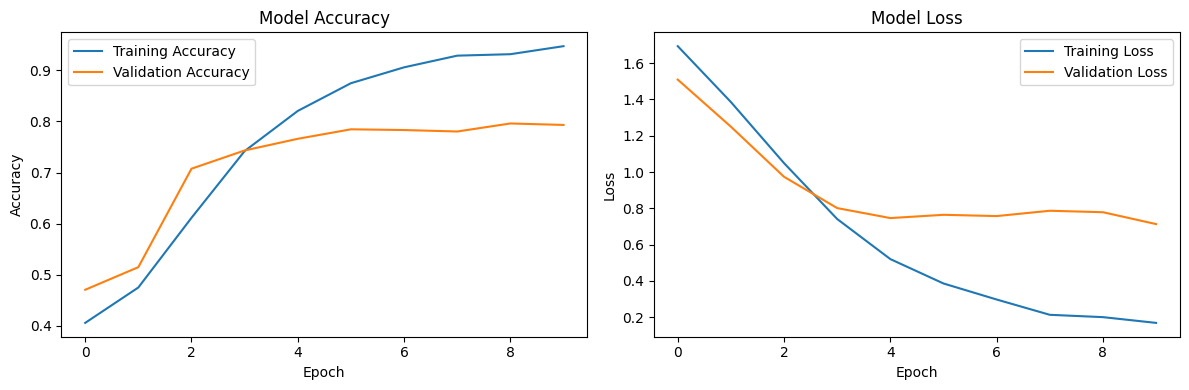

In [24]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

import matplotlib.pyplot as plt

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Model Performance Analysis

The model achieved a **Test Loss of 0.7290** and a **Test Accuracy of 0.8048**.

Looking at the training history plots:

*   **Accuracy:** The training accuracy consistently increased throughout the epochs, reaching over 0.9. However, the validation accuracy peaked around 0.79-0.80 and then leveled off. This suggests a slight overfitting, where the model performs very well on the training data but doesn't generalize as well to unseen validation data after a certain point. However, an 80% accuracy on unseen data is a good starting point.

*   **Loss:** Similarly, the training loss steadily decreased, while the validation loss decreased initially and then started to fluctuate or slightly increase, which is another indicator of mild overfitting.

Overall, the model shows good learning capabilities, but there's room for improvement by addressing the observed overfitting. Techniques like early stopping, more aggressive dropout, or regularization could be explored. However, for a first iteration, this is a solid performance.

### Predict on User Input

Now, let's create a function to predict the class of a new DNA sequence input by the user. We will use the same preprocessing steps as used for training.

In [25]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

def predict_dna_sequence(new_sequence, model, max_sequence_length, verbose=False):
    """
    Predicts the class of a new DNA sequence using the trained model.

    Args:
        new_sequence (str): The DNA sequence string to predict.
        model (tf.keras.Model): The trained Keras model.
        max_sequence_length (int): The maximum sequence length used during training.
        verbose (bool): If True, print intermediate preprocessing steps.

    Returns:
        tuple: Predicted class (integer) and prediction probabilities.
    """

    # One-hot encode the new sequence
    def one_hot_encode_dna_single(sequence):
        mapping = {'A': [1, 0, 0, 0], 'C': [0, 1, 0, 0], 'G': [0, 0, 1, 0], 'T': [0, 0, 0, 1], 'N': [0, 0, 0, 0]}
        encoded_sequence = [mapping.get(char, [0, 0, 0, 0]) for char in sequence]
        return np.array(encoded_sequence, dtype='float32')

    encoded_new_sequence = one_hot_encode_dna_single(new_sequence)
    if verbose: print(f"Encoded new sequence shape: {encoded_new_sequence.shape}")

    # Pad the sequence to the maximum length
    # pad_sequences expects a list of sequences, so wrap it
    padded_new_sequence = pad_sequences([encoded_new_sequence], maxlen=max_sequence_length, padding='post', dtype='float32')
    if verbose: print(f"Padded new sequence shape: {padded_new_sequence.shape}")

    # Make prediction
    predictions = model.predict(padded_new_sequence, verbose=0)
    predicted_class = np.argmax(predictions, axis=1)[0] + 1 # Add 1 back because classes were 0-indexed

    return predicted_class, predictions[0]

# Example usage:
# Let's take a sequence from our original dataframe for demonstration
example_sequence = df['sequence'].iloc[0]
actual_class = df['class'].iloc[0]

predicted_class, probabilities = predict_dna_sequence(example_sequence, model, max_sequence_length, verbose=True)

print(f"\nExample DNA Sequence: {example_sequence[:50]}...")
print(f"Actual Class: {actual_class}")
print(f"Predicted Class: {predicted_class}")
print(f"Prediction Probabilities: {probabilities.round(4)}")

Encoded new sequence shape: (207, 4)
Padded new sequence shape: (1, 18921, 4)

Example DNA Sequence: ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCATACT...
Actual Class: 4
Predicted Class: 6
Prediction Probabilities: [0.1049 0.0885 0.0397 0.0456 0.1085 0.6128]


### Streamlit User Interface

Now, let's create a Streamlit application to provide a user interface for predicting DNA sequence classes. You'll need to install Streamlit to run this locally. In Colab, you can run Streamlit apps, but it requires some setup (like `pip install streamlit`, `!npm install localtunnel`, and then running the app).

To run this code in a local environment, save the following code into a Python file (e.g., `app.py`) and run `streamlit run app.py` from your terminal.

In [28]:
!pip install -q streamlit
import streamlit as st
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model # Used if loading a saved model

# Assuming `model`, `max_sequence_length` are already defined from the notebook's execution
# In a real Streamlit app, you would load your trained model here:
# model = load_model('path/to/your/saved/model.h5')

# Define the one-hot encoding function (same as used in the notebook)
def one_hot_encode_dna_single(sequence):
    mapping = {'A': [1, 0, 0, 0], 'C': [0, 1, 0, 0], 'G': [0, 0, 1, 0], 'T': [0, 0, 0, 1], 'N': [0, 0, 0, 0]}
    encoded_sequence = [mapping.get(char, [0, 0, 0, 0]) for char in sequence]
    return np.array(encoded_sequence, dtype='float32')

# Define the prediction function (same as above, but adapted for Streamlit)
def predict_dna_sequence_streamlit(new_sequence, model, max_sequence_length):
    encoded_new_sequence = one_hot_encode_dna_single(new_sequence)
    padded_new_sequence = pad_sequences([encoded_new_sequence], maxlen=max_sequence_length, padding='post', dtype='float32')
    predictions = model.predict(padded_new_new_sequence, verbose=0)
    predicted_class = np.argmax(predictions, axis=1)[0] + 1
    return predicted_class, predictions[0]

# --- Streamlit UI ---
st.title('DNA Sequence Classification')
st.write('Enter a DNA sequence to predict its class.')

user_input = st.text_area('DNA Sequence', 'ATGCGTACGTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGC')

if st.button('Predict Class'):
    if user_input:
        try:
            # Ensure input is valid DNA sequence (A, C, G, T, N)
            if not all(char in 'ACGTNacgtn' for char in user_input):
                st.error('Invalid DNA sequence. Please use only A, C, G, T, N (case-insensitive).')
            else:
                # Convert to uppercase for consistency
                user_input_upper = user_input.upper()
                predicted_class, probabilities = predict_dna_sequence_streamlit(user_input_upper, model, max_sequence_length)

                st.success(f'Predicted Class: **{predicted_class}**')
                st.subheader('Prediction Probabilities:')
                # Display probabilities for each class
                class_labels = [f'Class {i+1}' for i in range(len(probabilities))]
                prob_df = pd.DataFrame({'Class': class_labels, 'Probability': probabilities.round(4)})
                st.dataframe(prob_df)

        except Exception as e:
            st.error(f'An error occurred during prediction: {e}')
    else:
        st.warning('Please enter a DNA sequence.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 85.3 MB/s eta 0:00:00


2026-07-20 14:00:03.923 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 14:00:04.141 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-20 14:00:04.141 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 14:00:04.143 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 14:00:04.144 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 14:00:04.145 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 14:00:04.146 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 14:00:04.146 Thread 'MainThread': mi

In [38]:
import tensorflow as tf

# Save the trained model
model.save('dna_classifier_model.h5')
print("Model saved as dna_classifier_model.h5")

# Save max_sequence_length to a file (or you can hardcode it in app.py if it's constant)
with open('max_sequence_length.txt', 'w') as f:
    f.write(str(max_sequence_length))
print(f"Max sequence length ({max_sequence_length}) saved to max_sequence_length.txt")

Model saved as dna_classifier_model.h5
Max sequence length (18921) saved to max_sequence_length.txt


In [46]:
%%writefile app.py
import streamlit as st
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(layout="centered") # Optional: Use 'wide' for wider layout

# --- Caching the model and max_sequence_length for performance ---
@st.cache_resource
def get_model(model_path):
    model = load_model(model_path)
    return model

@st.cache_data
def get_max_sequence_length(file_path):
    with open(file_path, 'r') as f:
        max_seq_len = int(f.read())
    return max_seq_len

model = get_model('dna_classifier_model.h5')
max_sequence_length = get_max_sequence_length('max_sequence_length.txt')

# Define human-readable class names
# IMPORTANT: Update these names according to your dataset's actual class meanings
# If you don't know the specific names, you can leave them as generic 'Class X'
CLASS_NAMES = {
    1: 'Class 1 (e.g., Promoter)',
    2: 'Class 2 (e.g., Enhancer)',
    3: 'Class 3 (e.g., Exon)',
    4: 'Class 4 (e.g., Intron)',
    5: 'Class 5 (e.g., Regulatory Region)',
    6: 'Class 6 (e.g., Coding Region)'
}

# Define the one-hot encoding function
def one_hot_encode_dna_single(sequence):
    mapping = {'A': [1, 0, 0, 0], 'C': [0, 1, 0, 0], 'G': [0, 0, 1, 0], 'T': [0, 0, 0, 1], 'N': [0, 0, 0, 0]}
    encoded_sequence = [mapping.get(char, [0, 0, 0, 0]) for char in sequence]
    return np.array(encoded_sequence, dtype='float32')

# Define the prediction function
@st.cache_data
def predict_dna_sequence_streamlit(new_sequence, model, max_sequence_length):
    encoded_new_sequence = one_hot_encode_dna_single(new_sequence)
    padded_new_sequence = pad_sequences([encoded_new_sequence], maxlen=max_sequence_length, padding='post', dtype='float32')
    predictions = model.predict(padded_new_sequence, verbose=0)
    predicted_class_id = np.argmax(predictions, axis=1)[0] + 1
    return predicted_class_id, predictions[0]

# --- Streamlit UI ---
st.title('🧬 DNA Sequence Classifier')
st.markdown("""
This application uses a Deep Learning model to classify DNA sequences into predefined categories.
Simply paste your DNA sequence below and click 'Predict Class' to get the classification.
""")

st.subheader('Enter Your DNA Sequence')
user_input = st.text_area('Paste DNA Sequence Here (A, C, G, T, N)', 'ATGCGTACGTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGC', height=150)

if st.button('🚀 Predict Class'):
    if user_input:
        with st.spinner('Analyzing sequence...'):
            try:
                # Ensure input is valid DNA sequence (A, C, G, T, N)
                if not all(char.upper() in 'ACGTN' for char in user_input):
                    st.error('🚫 Invalid DNA sequence. Please use only A, C, G, T, N (case-insensitive).')
                else:
                    user_input_upper = user_input.upper()
                    predicted_class_id, probabilities = predict_dna_sequence_streamlit(user_input_upper, model, max_sequence_length)
                    predicted_class_name = CLASS_NAMES.get(predicted_class_id, f'Unknown Class {predicted_class_id}')

                    st.success(f'✨ Prediction Complete! Predicted Class: **{predicted_class_name}**')
                    st.write(f"(Class ID: {predicted_class_id})")

                    st.subheader('📊 Prediction Probabilities')
                    prob_df = pd.DataFrame({
                        'Class': [CLASS_NAMES.get(i + 1, f'Class {i+1}') for i in range(len(probabilities))],
                        'Probability': probabilities.round(4)
                    })

                    # Sort probabilities for better visualization
                    prob_df = prob_df.sort_values(by='Probability', ascending=False)

                    fig, ax = plt.subplots(figsize=(10, 6))
                    sns.barplot(x='Probability', y='Class', data=prob_df, palette='viridis', ax=ax)
                    ax.set_title('Probability Distribution Across Classes')
                    ax.set_xlim(0, 1) # Probabilities are between 0 and 1
                    st.pyplot(fig)

                    st.markdown("**Note:** If your specific class names are different, please update the `CLASS_NAMES` dictionary in the application code.")

            except Exception as e:
                st.error(f'An unexpected error occurred during prediction: {e}')
    else:
        st.warning('⚠️ Please enter a DNA sequence to make a prediction.')


Overwriting app.py


Now that `app.py` has been updated to load the model and `max_sequence_length`, you can re-run the cell below to launch the Streamlit application with `localtunnel`.

In [47]:
!pip install -q pyngrok
from pyngrok import ngrok

# Set your ngrok authtoken here. Replace 'YOUR_NGROK_AUTH_TOKEN' with your actual token.
# You can get one from your ngrok dashboard: https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("3AbwaW53yv021tNxAXrWJumLaDB_7ooi3CHcXxwCCt7XaTCXX")

# Connect to the Streamlit port (8501)
public_url = ngrok.connect(8501)
print(f"Streamlit App URL: {public_url}")

# Ensure the Streamlit process started by the `localtunnel` command is still running.
# If not, you might need to re-run the `!streamlit run app.py & npx localtunnel --port 8501` command
# in the previous cell first, then execute this cell to get the ngrok URL.

Streamlit App URL: NgrokTunnel: "https://foraminate-anders-uncovetous.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
# Restart the Streamlit app and expose it via localtunnel
# The '&' runs streamlit in the background, and 'npx localtunnel' then tunnels the port.
# You will see a public URL printed, which you can click to access your Streamlit app.
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹



your url is: https://puny-schools-divide.loca.lt


2026-07-20 14:12:09.030 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.138.190.229:8501

2026-07-20 14:12:20.868723: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1784556740.870297    7618 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5441 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-07-20 14:12:22.249250: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 309854208 exceeds 10% of free system memory.
2026-07-20 14:12:26.456828: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 309854208 exceeds 10% of free system memory.
I0000 00:00:1784556750.0714

### Run the Streamlit Application in Colab

To run the Streamlit application in Google Colab, we need to save the Streamlit code to a Python file, install `localtunnel` (a tool to expose a local server to the internet), and then launch the Streamlit app using a shell command. The public URL will be provided in the output.

In [35]:
# Install localtunnel to expose the Streamlit app
!npm install localtunnel

# Run the Streamlit app and expose it via localtunnel
# The '&' runs streamlit in the background, and 'npx localtunnel' then tunnels the port.
# You will see a public URL printed, which you can click to access your Streamlit app.
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧
up to date, audited 23 packages in 1s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠇⠙

your url is: https://stale-parts-grab.loca.lt
2026-07-20 14:04:24.873 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.138.190.229:8501

  Stopping...
^C


In [34]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://foraminate-anders-uncovetous.ngrok-free.dev" -> "http://localhost:8501"
